### Task 1: Baseline with Single Models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

sns.set_style("whitegrid")

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=";")

# Create binary target
wine["quality_label"] = (wine["quality"] >= 7).astype(int)  # 1 = good, 0 = not good

# Basic exploration
print("Dataset shape:", wine.shape)
print("\nColumns:")
print(wine.columns.tolist())

print("\nFirst 5 rows:")
display(wine.head())

print("\nClass distribution of quality_label:")
print(wine["quality_label"].value_counts())

print("\nClass distribution (normalized):")
print(wine["quality_label"].value_counts(normalize=True))

# Check number of features
X = wine.drop(["quality", "quality_label"], axis=1)
y = wine["quality_label"]

print("\nNumber of features:", X.shape[1])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    # Tree does not need scaling, but scaled version also works for consistency
    if name == "Decision Tree":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="binary")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1
    })

baseline_results = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)

# Store baseline scores as variables for use in final comparison table
dt_acc = next(r["Accuracy"] for r in results if r["Model"] == "Decision Tree")
dt_f1 = next(r["F1 Score"] for r in results if r["Model"] == "Decision Tree")
lr_acc = next(r["Accuracy"] for r in results if r["Model"] == "Logistic Regression")
lr_f1 = next(r["F1 Score"] for r in results if r["Model"] == "Logistic Regression")
knn_acc = next(r["Accuracy"] for r in results if r["Model"] == "KNN")
knn_f1 = next(r["F1 Score"] for r in results if r["Model"] == "KNN")

print("Baseline Model Results:")
display(baseline_results)

Dataset shape: (1599, 13)

Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'quality_label']

First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0



Class distribution of quality_label:
quality_label
0    1382
1     217
Name: count, dtype: int64

Class distribution (normalized):
quality_label
0    0.86429
1    0.13571
Name: proportion, dtype: float64

Number of features: 11
Baseline Model Results:


,Model,Accuracy,F1 Score
0,Decision Tree,0.90000,0.644444
2,KNN,0.89375,0.514286
1,Logistic Regression,0.89375,0.484848


### Dataset Exploration

The dataset contains 1599 samples and 13 columns, including 11 input features and 2 target-related columns (`quality` and `quality_label`). The features describe physicochemical properties of wine such as acidity, pH, alcohol, and sulphates.

After creating the binary target (`quality_label`), I examined the class distribution. The dataset is clearly imbalanced:
- Class 0 (not good): 1382 samples (~86%)
- Class 1 (good): 217 samples (~14%)

This imbalance means that accuracy alone is not a reliable metric, so the F1 score is also used to better evaluate model performance.

---

### Model Training and Evaluation

Three baseline models were trained: Decision Tree, Logistic Regression, and K-Nearest Neighbors. The dataset was split into training and test sets (80/20) using stratification to preserve class proportions. Feature scaling was applied for Logistic Regression and KNN, as these models are sensitive to feature magnitude.

---

### Results Interpretation

The performance of the baseline models is shown below:

- Decision Tree: Accuracy = 0.90, F1 Score = 0.64
- KNN: Accuracy ≈ 0.89, F1 Score ≈ 0.51
- Logistic Regression: Accuracy ≈ 0.89, F1 Score ≈ 0.48

Although all models achieved similar accuracy, the Decision Tree clearly performed better in terms of F1 score. This indicates that it handles the minority class (good quality wines) more effectively than the other models.

The lower F1 scores for Logistic Regression and KNN suggest that these models struggle to correctly identify the minority class due to class imbalance.

---

### Conclusion

Among the baseline models, the Decision Tree achieved the best overall performance, especially in terms of F1 score. Therefore, it will serve as a strong reference point for evaluating ensemble methods in the next tasks. We expect ensemble techniques such as bagging and Random Forest to improve performance further, especially by reducing variance and handling imbalance more effectively.

### Task 2: Bagging & Random Forest

In [2]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

# Bagging
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)

y_pred_bagging = bagging.predict(X_test)

bagging_acc = accuracy_score(y_test, y_pred_bagging)
bagging_f1 = f1_score(y_test, y_pred_bagging)

print("Bagging Results:")
print("OOB Score:", bagging.oob_score_)
print("Accuracy:", bagging_acc)
print("F1 Score:", bagging_f1)


# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("\nRandom Forest Results:")
print("OOB Score:", rf.oob_score_)
print("Accuracy:", rf_acc)
print("F1 Score:", rf_f1)


Bagging Results:
OOB Score: 0.8975762314308053
Accuracy: 0.9375
F1 Score: 0.7368421052631579

Random Forest Results:
OOB Score: 0.8991399530883503
Accuracy: 0.94375
F1 Score: 0.75


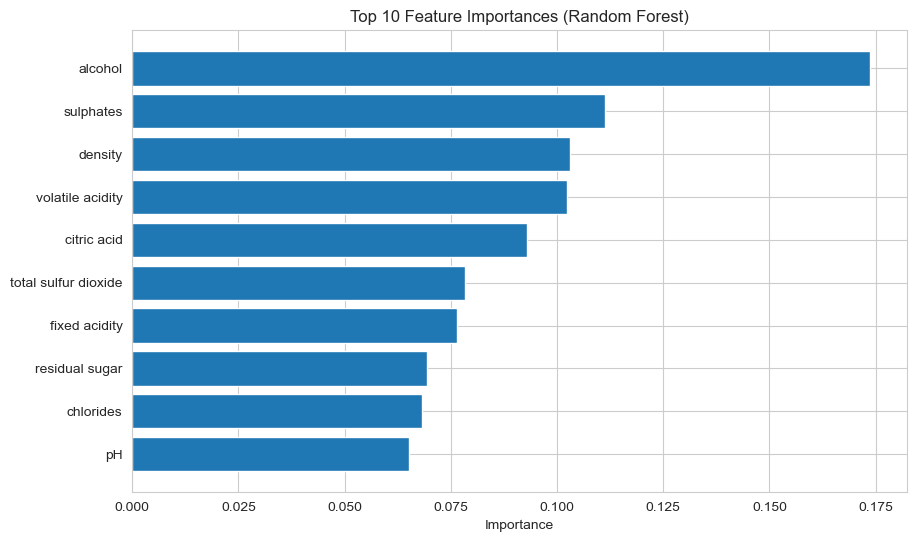

In [3]:
#Feature Importance Plot

import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=True).tail(10)

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()

### Bagging and Random Forest
In this task, I applied two ensemble methods: Bagging and Random Forest. Both methods combine multiple Decision Trees to improve performance compared to a single model.
Bagging works by training multiple trees on different bootstrap samples of the data and combining their predictions using majority voting. This helps reduce variance and makes the model more stable.
Random Forest extends this idea by introducing additional randomness. At each split, only a random subset of features is considered, which makes the trees less correlated and improves generalization.

---

### Results and Comparison
The results show a clear improvement over the baseline Decision Tree:
- Decision Tree (baseline): F1 Score = 0.64  
- Bagging: F1 Score ≈ 0.74  
- Random Forest: F1 Score ≈ 0.75  

Both ensemble methods significantly improved performance, especially in terms of F1 score, which is important for this imbalanced dataset.

Random Forest slightly outperformed Bagging:
- Bagging Accuracy: 0.9375 | F1 ≈ 0.737  
- Random Forest Accuracy: 0.94375 | F1 ≈ 0.75  

The OOB scores (~0.898–0.899) are close to the test accuracy, indicating that the models generalize well and are not heavily overfitting.

---
### Feature Importance
The feature importance plot shows which variables contribute the most to predicting wine quality.

The most important features are:
- Alcohol (by far the most important)
- Sulphates
- Density
- Volatile acidity

This suggests that alcohol content plays a major role in determining wine quality, followed by chemical balance indicators.

---
### Why Random Forest Performs Better
Random Forest performs better than a single Decision Tree because it reduces variance by averaging multiple trees. Additionally, feature randomness ensures that trees are more diverse and less correlated.
This diversity leads to a more robust and stable model that performs better on unseen data.

### Task 3: Boosting

In [4]:
#Boosting Models

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# AdaBoost
ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

ada_acc = accuracy_score(y_test, y_pred_ada)
ada_f1 = f1_score(y_test, y_pred_ada)

print("AdaBoost Results:")
print("Accuracy:", ada_acc)
print("F1 Score:", ada_f1)


# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

gb_acc = accuracy_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)

print("\nGradient Boosting Results:")
print("Accuracy:", gb_acc)
print("F1 Score:", gb_f1)

AdaBoost Results:
Accuracy: 0.89375
F1 Score: 0.43333333333333335

Gradient Boosting Results:
Accuracy: 0.915625
F1 Score: 0.6197183098591549


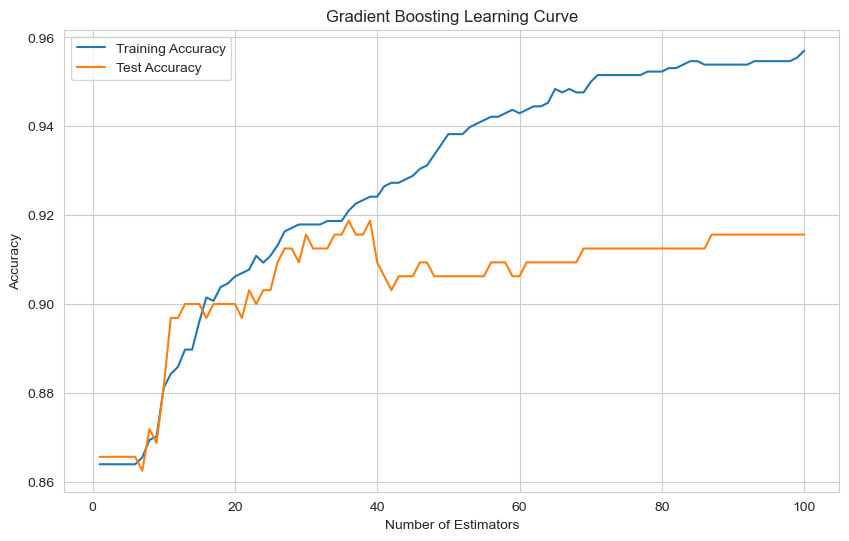

In [5]:
#LEARNING CURVE

train_scores = []
test_scores = []

for y_pred_train in gb.staged_predict(X_train):
    train_scores.append(accuracy_score(y_train, y_pred_train))

for y_pred_test in gb.staged_predict(X_test):
    test_scores.append(accuracy_score(y_test, y_pred_test))


plt.figure(figsize=(10,6))
plt.plot(range(1, len(train_scores)+1), train_scores, label="Training Accuracy")
plt.plot(range(1, len(test_scores)+1), test_scores, label="Test Accuracy")

plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting Learning Curve")
plt.legend()
plt.grid(True)

plt.show()

### Boosting Models

In this task, I trained two boosting models: AdaBoost and Gradient Boosting. Unlike bagging, boosting methods build models sequentially, where each new model focuses on correcting the mistakes of the previous ones.

AdaBoost increases the weight of misclassified samples, forcing subsequent models to focus more on difficult cases. Gradient Boosting, on the other hand, fits each new model to the residual errors of the previous ensemble, making it a more flexible and powerful approach.

---

### Results and Comparison

The performance of the boosting models is as follows:

- AdaBoost: Accuracy = 0.89375, F1 Score ≈ 0.43  
- Gradient Boosting: Accuracy = 0.9156, F1 Score ≈ 0.62  

AdaBoost performed significantly worse than the other models, especially in terms of F1 score. This suggests that it struggled to correctly classify the minority class, likely due to sensitivity to noise and class imbalance.

Gradient Boosting performed much better and is comparable to earlier ensemble methods like Bagging and Random Forest. However, it still does not outperform Random Forest (F1 ≈ 0.75), indicating that variance reduction worked better than bias reduction for this dataset.

---

### Learning Curve Analysis

The learning curve shows how model performance changes as the number of estimators increases.

- Training accuracy steadily increases throughout the boosting process.
- Test accuracy improves initially but starts to plateau around 30–40 estimators.
- After this point, the gap between training and test accuracy widens slightly.

This indicates the beginning of overfitting. While the model continues to learn patterns from training data, it does not generalize as well to unseen data after a certain number of estimators.

The optimal number of estimators appears to be around 30–40, where test performance is highest.

---

### AdaBoost vs Gradient Boosting

AdaBoost is simpler and focuses on reweighting misclassified samples. However, it is sensitive to noise and can struggle with imbalanced datasets, as seen in the low F1 score.

Gradient Boosting is more advanced and directly minimizes prediction errors by fitting residuals. It is generally more robust and flexible, which explains its better performance in this task.

In practice, Gradient Boosting is preferred when higher predictive performance is required.

### Task 4: Stacking & Voting

In [6]:
# Select the best 3 models based on previous tasks

from sklearn.ensemble import VotingClassifier, StackingClassifier

best_models = [
    ("rf", RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42, n_jobs=-1)),
    ("bagging", BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )),
    ("gb", GradientBoostingClassifier(n_estimators=100, random_state=42))
]

# Voting Classifier (soft voting)
voting_clf = VotingClassifier(
    estimators=best_models,
    voting="soft",
    n_jobs=-1
)

voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_test)

voting_acc = accuracy_score(y_test, y_pred_voting)
voting_f1 = f1_score(y_test, y_pred_voting)

print("Voting Classifier Results:")
print("Accuracy:", voting_acc)
print("F1 Score:", voting_f1)


# Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=best_models,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

stacking_clf.fit(X_train, y_train)
y_pred_stacking = stacking_clf.predict(X_test)

stacking_acc = accuracy_score(y_test, y_pred_stacking)
stacking_f1 = f1_score(y_test, y_pred_stacking)

print("\nStacking Classifier Results:")
print("Accuracy:", stacking_acc)
print("F1 Score:", stacking_f1)

Voting Classifier Results:
Accuracy: 0.934375
F1 Score: 0.704225352112676

Stacking Classifier Results:
Accuracy: 0.940625
F1 Score: 0.7323943661971831


In [7]:
# Final comparison table
all_results = pd.DataFrame([
    {"Model": "Decision Tree", "Accuracy": dt_acc, "F1 Score": dt_f1},
    {"Model": "Logistic Regression", "Accuracy": lr_acc, "F1 Score": lr_f1},
    {"Model": "KNN", "Accuracy": knn_acc, "F1 Score": knn_f1},
    {"Model": "Bagging", "Accuracy": bagging_acc, "F1 Score": bagging_f1},
    {"Model": "Random Forest", "Accuracy": rf_acc, "F1 Score": rf_f1},
    {"Model": "AdaBoost", "Accuracy": ada_acc, "F1 Score": ada_f1},
    {"Model": "Gradient Boosting", "Accuracy": gb_acc, "F1 Score": gb_f1},
    {"Model": "Voting Classifier", "Accuracy": voting_acc, "F1 Score": voting_f1},
    {"Model": "Stacking Classifier", "Accuracy": stacking_acc, "F1 Score": stacking_f1},
])

all_results = all_results.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

print("Final Model Comparison:")
display(all_results)

Final Model Comparison:


,Model,Accuracy,F1 Score
0,Random Forest,0.943750,0.750000
1,Bagging,0.937500,0.736842
2,Stacking Classifier,0.940625,0.732394
3,Voting Classifier,0.934375,0.704225
4,Decision Tree,0.900000,0.644444
5,Gradient Boosting,0.915625,0.619718
6,KNN,0.893750,0.514286
7,Logistic Regression,0.893750,0.484848
8,AdaBoost,0.893750,0.433333


### Voting and Stacking Ensembles

In this task, I combined the best-performing models from previous tasks (Random Forest, Bagging, and Gradient Boosting) using two ensemble strategies: a soft Voting Classifier and a Stacking Classifier.

The Voting Classifier combines the predicted probabilities of the base models and selects the final class based on the average probability. This method is simple and effective when the individual models are strong.

The Stacking Classifier uses a meta-model (Logistic Regression) to learn how to best combine the predictions of the base models. It takes the outputs of the base learners as input features and optimizes their combination.

---

### Results and Comparison

The results of the ensemble combinations are:

- Voting Classifier: Accuracy = 0.9344, F1 Score ≈ 0.704  
- Stacking Classifier: Accuracy = 0.9406, F1 Score ≈ 0.732  

Stacking performed better than Voting, showing that learning how to combine models is more effective than simply averaging their predictions.

The final comparison of all models shows:

- Random Forest achieved the best overall performance (F1 = 0.75)
- Bagging and Stacking also performed strongly (F1 ≈ 0.73–0.74)
- Voting provided moderate improvement
- Boosting methods gave mixed results (Gradient Boosting decent, AdaBoost weak)
- Baseline models performed significantly worse

---

### Final Conclusion

The results clearly show that ensemble methods significantly improve performance compared to single models.

Among all approaches, Random Forest was the best-performing model. It achieved the highest F1 score and maintained strong accuracy, making it the most reliable choice for this dataset.

Stacking also performed very well, showing that combining different models through a meta-learner can be highly effective. However, it introduces additional complexity and requires more computation.

Voting was simpler but slightly less effective than stacking, as it does not learn how to optimally combine models.

Boosting methods did not outperform Random Forest in this case, likely due to the class imbalance and sensitivity to noise.

---

### Recommendation

For a real-world wine quality prediction system, Random Forest would be the best choice. It offers:

- Strong predictive performance
- Good handling of class imbalance
- Robustness against overfitting
- Interpretability through feature importance

Although more complex ensemble methods like stacking can improve performance, the added complexity may not justify the small gain in this case.

Overall, Random Forest provides the best balance between performance, simplicity, and reliability.